[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brilliantbeaver/alexpose/blob/main/experiments/sjepa/gavd5-drift/neurips-brain-body/00_sjepa_from_first_principles.ipynb)

# 00. S-JEPA from first principles

## Motivation: what should a masked skeleton model learn?

Before reading training curves, we need to know what the model is asked to predict. This notebook builds a small teaching model that predicts missing **representations** of a skeleton, not missing coordinates or a diagnosis. Look for three things: where information enters each branch, which tokens become targets, and which parameters receive gradients.

**Evidence status:** the final trace uses two hand-authored synthetic walks, even when the setup prints `mode: real`. It checks software behavior, not performance on GAVD. This teaching architecture is different from the compact model actually trained in [notebook 04](04_pretrain_sjepa_on_normal.ipynb); the comparison below identifies the differences.

Read in order: setup and method diagrams; source-level evaluation; tokens and objectives; input preparation; masking; model classes; one forward/backward trace; interpretations. You need only basic Python and the idea that a neural network converts numbers into learned features.

Locally, run `uv sync` and `uv run jupyter lab neurips-brain-body` from the experiment folder. Restart the kernel after changing its `.env`. Setup can install packages in Colab; the final rendering cell writes figure assets. Reading saved outputs requires neither training nor downloads.

Research use only. Nothing in this notebook diagnoses a person or validates a clinical device.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/brilliantbeaver/alexpose.git"

if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "numpy", "pandas", "scipy", "scikit-learn", "matplotlib",
        "seaborn", "torch", "tqdm", "python-dotenv", "yt-dlp[default]",
        "opencv-python-headless", "mediapipe<1", "joblib", "pyarrow",
    ])
    clone_dir = Path("/content/alexpose")
    if not (clone_dir / ".git").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)])
    os.chdir(clone_dir)


def find_project_root(start=None):
    env_root = os.getenv("ALEXPOSE_ROOT")
    if env_root:
        candidate = Path(env_root).expanduser().resolve()
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
        print(f"Ignoring invalid ALEXPOSE_ROOT: {candidate}")
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "data" / "gavd").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift"
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"

try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except Exception:
    pass

MODE = os.getenv("GAVD_MODE", "smoke").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print(
        "SMOKE MODE: hand-authored motions test code paths only. "
        "They have no pathophysiological or clinical validity."
    )

PREFERRED_ROOT = Path(
    os.getenv(
        "GAVD4_ROOT",
        "/Users/pmui/vaults/worldmodels/gait/skeleton-jepa/gavd4",
    )
).expanduser()

requested_data = os.getenv("GAVD4_DATA_DIR") or os.getenv("GAVD_DATA_GAVD_DIR")
if requested_data and Path(requested_data).expanduser().exists():
    DATA_GAVD_DIR = Path(requested_data).expanduser()
elif requested_data:
    print(f"Ignoring missing GAVD CSV path: {Path(requested_data).expanduser()}")
    if (EXPERIMENT_DIR / "data-gavd").exists():
        DATA_GAVD_DIR = EXPERIMENT_DIR / "data-gavd"
    elif (PREFERRED_ROOT / "data-gavd").exists():
        DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
    else:
        DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"
elif (EXPERIMENT_DIR / "data-gavd").exists():
    DATA_GAVD_DIR = EXPERIMENT_DIR / "data-gavd"
elif (PREFERRED_ROOT / "data-gavd").exists():
    DATA_GAVD_DIR = PREFERRED_ROOT / "data-gavd"
else:
    DATA_GAVD_DIR = PROJECT_ROOT / "data" / "gavd"

requested_youtube = os.getenv("GAVD4_YOUTUBE_DIR") or os.getenv("GAVD_YOUTUBE_DIR")
if requested_youtube:
    YOUTUBE_DIR = Path(requested_youtube).expanduser()
elif PREFERRED_ROOT.exists():
    YOUTUBE_DIR = PREFERRED_ROOT / "youtube"
else:
    YOUTUBE_DIR = PROJECT_ROOT / "experiments" / "sjepa" / "gavd5-drift" / "work" / "youtube"

CACHE_DIR = Path(
    os.getenv("GAVD_CACHE_DIR", EXPERIMENT_DIR / "work" / "cache")
).expanduser()
ARTIFACT_ROOT = Path(
    os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg-cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import SVG, display


def show_tutorial_svg(filename):
    '''Render a repository SVG reliably in local Jupyter and Colab.'''
    path = EXPERIMENT_DIR / "images" / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing tutorial figure {path}. Clone the full alexpose repository."
        )
    display(SVG(filename=str(path)))

print(f"mode: {MODE}")
print(f"project: {PROJECT_ROOT}")
print(f"workshop notebooks: {NOTEBOOK_DIR}")
print(f"GAVD CSVs: {DATA_GAVD_DIR}")
print(f"YouTube cache: {YOUTUBE_DIR}")
print(f"artifacts: {ARTIFACT_DIR}")


mode: real
project: C:\Users\alexm\dev\alexpose
workshop notebooks: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\neurips-brain-body
GAVD CSVs: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\data-gavd
YouTube cache: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\youtube
artifacts: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real


## Before the diagrams: check the execution context

The setup prints where data, videos, and artifacts would be found. Confirm those paths before running other notebooks. `real` selects an artifact directory; it does not make every demonstration empirical. All motion data created in this notebook's trace are synthetic.

The first diagram is a conceptual comparison. Read its target boxes first; do not interpret box sizes or arrows as performance measurements.


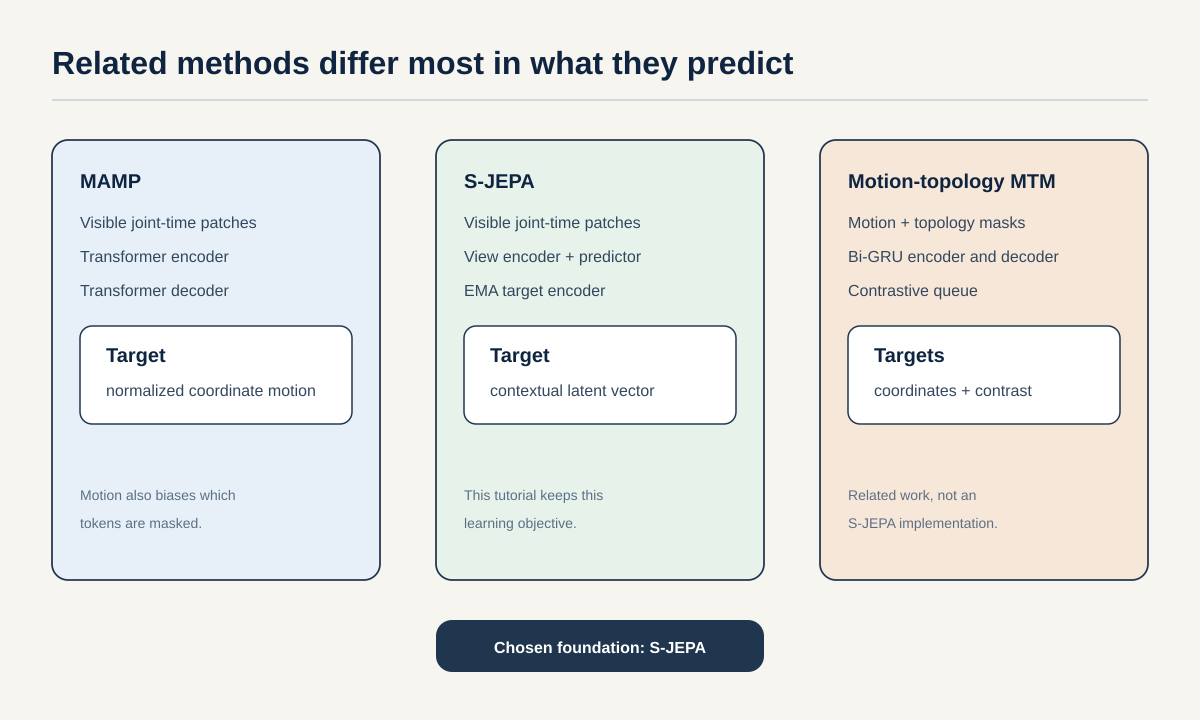

In [2]:
show_tutorial_svg("01_method_family.svg")


## Step 1. Separate a training target from a test example

Masking hides some information **inside a training clip**. A train/test split withholds entire examples from learning. These solve different problems.

Several annotated clips can come from one upload and share people, camera settings, background, and tracking errors. Protocol v2 therefore groups by `video_id`: every clip from an upload has the same role within a fold. An upload is the available grouping unit, not a verified unique person; the same person could appear in different uploads.

The next diagram describes the intended protocol: fit on training sources, select settings on validation sources, and evaluate frozen choices on test sources. Five outer folds are registered, but the current empirical package completes only fold 0 / seed 42. “Opened once” and “zero leakage” in the static graphic express design rules, not proof of the complete research history. Source disjointness can be checked; past researcher access cannot be established from this diagram.

Notebook 01 freezes roles from a dated public-URL snapshot. Later acquisition and pose failures are recorded against those roles rather than triggering a new split.


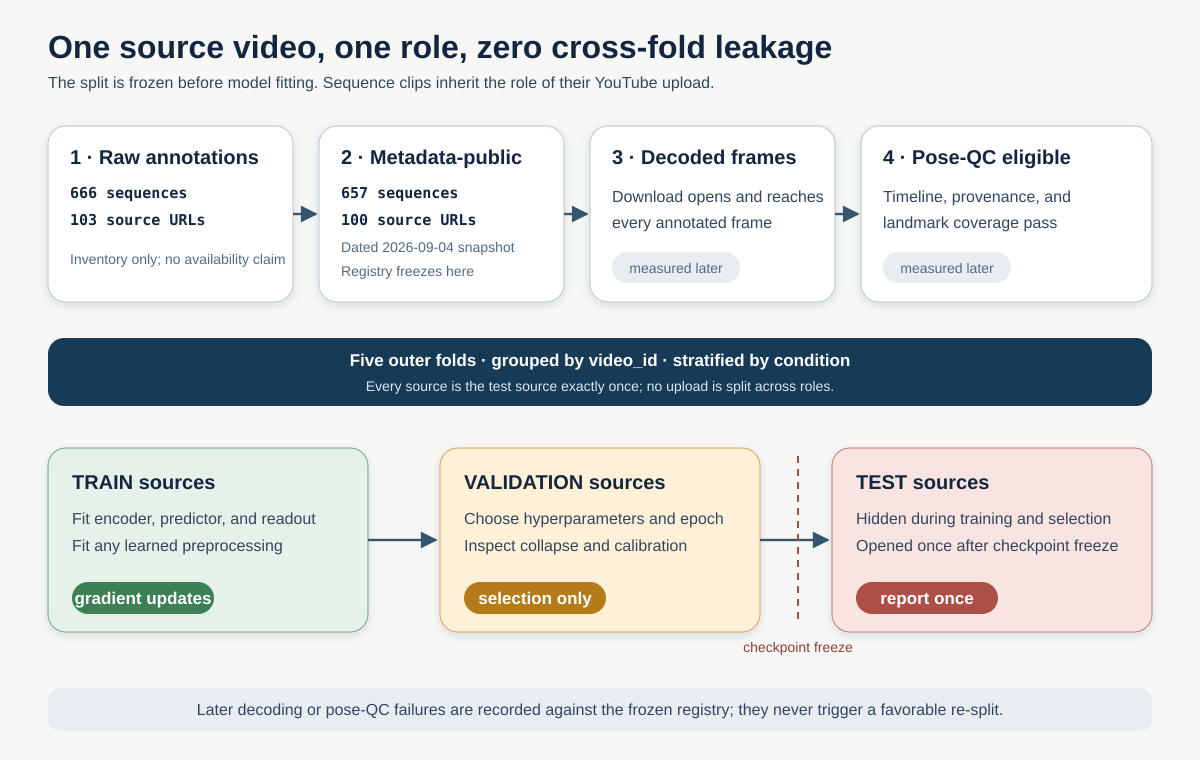

In [3]:
show_tutorial_svg("22_inductive_source_split.svg")


## Step 2. Understand the object being predicted

An **encoder** maps coordinates to learned vectors called embeddings or latents. A **predictor** tries to estimate a target latent from incomplete context. An EMA target encoder is a slowly updated copy of the trainable encoder, not a clinical teacher or a source of ground-truth diagnoses.

A joint-time patch groups one landmark across a short segment. With 64 frames, four frames per patch, and 33 landmarks, there are `16 × 33 = 528` token positions. In this notebook, each patch is flattened into `4 × 3 = 12` coordinate values before projection. The small trace later uses 32 frames, hence 264 positions.

The target encoder processes the full clip before we select its target vectors. This gives each target access to other joints and times. The student must estimate those vectors from less input. Predicting part of an already observed clip is **contextual infilling**, not a demonstrated forecast of a later event.


## Background: read the method-family graphic by its target

The opening graphic compares design ideas, not measured results from this notebook.

| Design | What is predicted or matched? | What to learn from the comparison |
|---|---|---|
| MAMP | Coordinate-motion targets | A reconstruction objective can operate directly on motion. |
| Published S-JEPA | Contextual target-encoder representations | The error is measured in learned feature space. |
| Motion-topology MTM | Reconstruction and contrastive objectives | A hybrid can combine several learning signals. |

No MAMP or MTM baseline is trained here. The graphic's “chosen foundation” identifies an inspiration; it does not imply an exact reproduction or a demonstrated advantage.


### Coordinate reconstruction versus latent prediction

Suppose an ankle moves between frames. A coordinate-motion target can describe the change `X[t+1] - X[t]`. A latent target is instead the output of an encoder that has considered the surrounding skeleton. Its dimensions do not have names such as “ankle angle” unless an additional analysis establishes that relationship.

[MAMP](https://github.com/maoyunyao/MAMP) is background for the first approach. The relevant practical question here is simple: inspect the loss function to see whether it compares coordinates or learned vectors. In this notebook it compares distributions formed from learned vectors; in notebook 04 it compares learned vectors with Smooth-L1.


### A hybrid method is not this implementation

The [motion-topology MTM paper](https://www.nature.com/articles/s41598-026-39330-9) combines motion/topology-guided masking with reconstruction and contrastive learning. Its design is separate from this notebook's fixed-set uniform sampler.

The next architecture graphic describes this notebook's teaching path: follow the student input to the predictor and the full input to the EMA target. The “Latent CE” box means latent cross-entropy. It does **not** describe notebook 04's current Smooth-L1 objective. Arrows show information or parameter updates, not empirical evidence that the model learned useful health features.


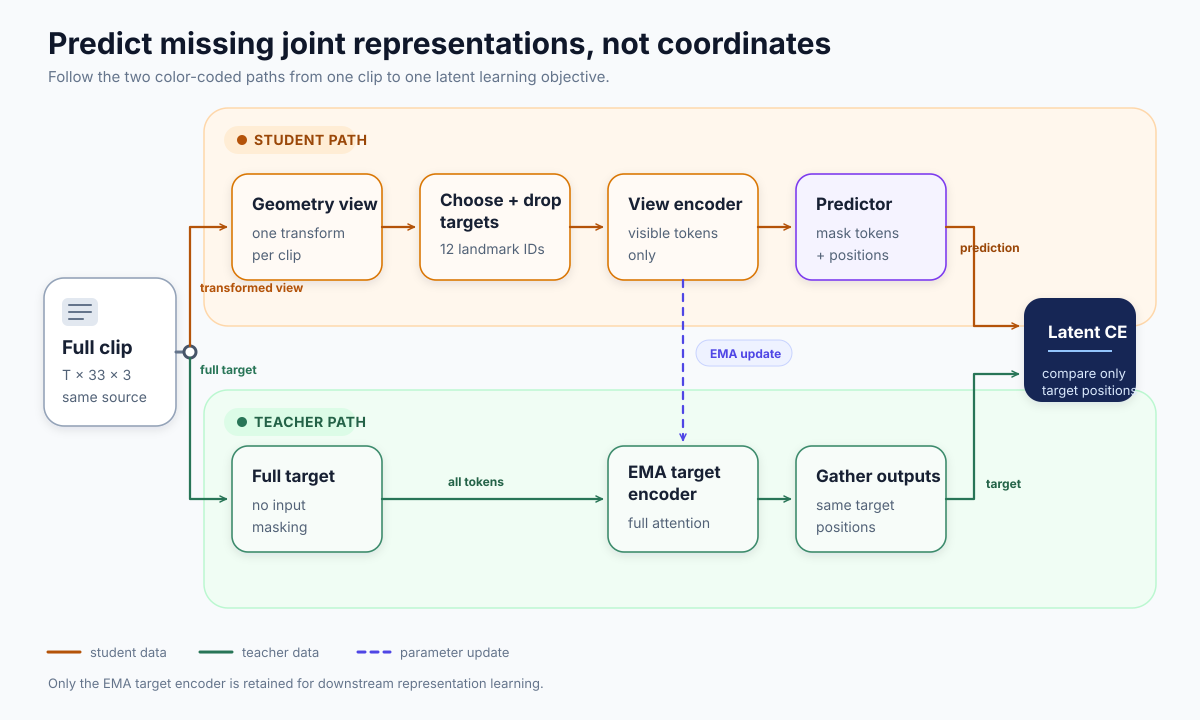

In [4]:
show_tutorial_svg("02_sjepa_architecture.svg")


## Step 3. Follow the teaching model, one operation at a time

1. Group each joint's four frames and project the resulting 12 numbers into a token.
2. Add trainable joint and time positions so the model can distinguish locations.
3. Build one small geometric view of the whole sequence.
4. Remove the selected target tokens before the trainable view encoder.
5. Place encoded visible tokens and learned mask tokens back into a complete layout.
6. Use a Transformer predictor to estimate vectors at the selected positions.
7. Encode the full unmasked target sequence without gradients and gather the corresponding target vectors.
8. Compare the predicted and target feature distributions with cross-entropy.
9. During a training loop, one would update student parameters, EMA teacher parameters, and the running target center.

The last step is a description of the provided update methods. The saved trace only calls `loss.backward()`: it does not call an optimizer step, `update_target`, or `update_center`. No full training run occurs here.

This teaching code has no VICReg projector or condition-centroid objective. Those older descriptions have been removed. The current notebook 04 uses a different implementation, described below.


## Step 4. Read the loss without treating it as accuracy

For each selected token, the target vector is centered and converted to a soft distribution. The predicted vector is converted to log probabilities:

$$
q=\operatorname{softmax}((R_t-c)/0.06),\qquad
\log p=\operatorname{logsoftmax}(R_p/0.10),\qquad
L=-\operatorname{mean}_{\text{targets}}\sum_d q_d\log p_d.
$$

Here, $d$ indexes embedding dimensions, **not disease classes**. The temperatures control how concentrated the distributions are. The teacher vector is detached, so this loss changes the student but supplies no teacher gradients. The registered center starts at zero.

EMA means a weighted average of old teacher parameters and new student parameters: $\theta_t \leftarrow m\theta_t+(1-m)\theta_s$. The provided helper varies $m$ from 0.996 toward 1, but is not exercised by the trace. A finite loss means the arithmetic succeeded; a lower loss would not by itself establish useful representations or rule out collapse.

The latent-target idea and centered cross-entropy are grounded in the [published S-JEPA method](https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/04755.pdf). Local implementation details should be read from the code here, not inferred from the paper.


## Important handoff: notebook 00 is not the trained notebook 04 model

| Component | This notebook's teaching model | Current notebook 04 model |
|---|---|---|
| Four-frame patch | Flatten 12 coordinates, then project | Average four frames into xyz, then project |
| Student input | Selected tokens removed | Full token layout retained; selected inputs replaced by a mask token |
| Predictor | Transformer over restored token layout | Mean visible-valid context plus target position, followed by an MLP |
| Main target loss | Centered soft-target cross-entropy | Smooth-L1 between latent vectors |
| Anti-collapse regularization | No additional regularizer in this trace | 0.10 variance term + 0.01 covariance term |
| Condition supervision | No training curriculum executed here | Optional group head exists but is disabled in the current primary run |
| Short-gap interpolation | Included in `prepare_sequence` here | Not included in current 04–06 preparation |

An MLP is a small feed-forward network. Variance and covariance penalties encourage spread and discourage redundant feature dimensions; they are not guarantees of usefulness. The current 04 objective has no separate two-view invariance term.

Notebook 04 uses a cumulative schedule: normal; normal + Parkinson's; then + stroke; then + myopathic; then + cerebral palsy. Earlier groups remain available, and sampling is uniform over sources and then clips within a source, not equal across condition groups. Annotation labels define this schedule, even though the primary representation loss does not use a condition label. These stages are an experimental exposure order, not a model of a person's disease progression.

Read notebook 04 for the actual checkpoint configuration, selection rules, and saved training history.


In [5]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
MASK_KEYPOINT_NAMES = [
    "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE",
    "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX",
]
assert MASK_KEYPOINTS == sorted(set(MASK_KEYPOINTS))
assert [BLAZEPOSE_33[i] for i in MASK_KEYPOINTS] == MASK_KEYPOINT_NAMES


## Step 5. Create a controlled input and keep missingness explicit

The next generator hand-writes joint trajectories and adds small random noise. Its condition strings are convenient fixture names, not simulations validated against those conditions. Successful separation of these fixtures would only show that a model can recover differences we inserted.

The following preparation functions accept `[time, 33, 4]`: three coordinate channels plus visibility. They mark finite landmarks with visibility at least 0.45 as valid; interpolate only short internal gaps of at most four frames; center on the hips; divide by a within-clip shoulder/hip scale; and resize the time axis. The original validity mask is carried separately, so filling a coordinate does not make it an observed target.

Normalized coordinates are not calibrated metres. Full-clip scaling and interpolation use information from throughout the clip and are not past-only forecasting operations.


In [6]:
def synthetic_gait_sequence(condition="normal", frames=64, seed=0):
    '''Create a code-path fixture, not a physiological disease simulation.'''
    rng = np.random.default_rng(seed)
    phase = np.linspace(0.0, 4.0 * np.pi, frames, endpoint=False)
    seq = np.zeros((frames, 33, 4), dtype=np.float32)
    seq[..., 3] = 1.0
    base = {
        11: (0.42, 0.28), 12: (0.58, 0.28),
        23: (0.45, 0.52), 24: (0.55, 0.52),
        25: (0.44, 0.70), 26: (0.56, 0.70),
        27: (0.43, 0.89), 28: (0.57, 0.89),
        29: (0.42, 0.92), 30: (0.58, 0.92),
        31: (0.39, 0.94), 32: (0.61, 0.94),
    }
    for joint, (x, y) in base.items():
        seq[:, joint, 0] = x
        seq[:, joint, 1] = y
    amplitude = 0.045
    lift = 0.025
    if condition == "parkinsons":
        amplitude *= 0.45
        lift *= 0.45
    if condition == "myopathic":
        seq[:, [11, 12], 0] += 0.03 * np.sin(phase)[:, None]
        seq[:, [23, 24], 0] += 0.018 * np.sin(phase)[:, None]
    for joint, knee, foot, offset in [(27, 25, 31, 0.0), (28, 26, 32, np.pi)]:
        wave = np.sin(phase + offset)
        if condition == "stroke" and joint == 27:
            wave = 0.35 * wave
        if condition == "cerebralpalsy":
            seq[:, knee, 1] -= 0.045
            seq[:, joint, 1] -= 0.02
        seq[:, joint, 0] += amplitude * wave
        seq[:, knee, 0] += 0.4 * amplitude * wave
        seq[:, foot, 0] += amplitude * wave
        seq[:, joint, 1] -= lift * np.maximum(wave, 0.0)
        seq[:, foot, 1] -= 0.7 * lift * np.maximum(wave, 0.0)
    seq[..., :3] += rng.normal(0.0, 0.0025, seq[..., :3].shape)
    return seq


def synthetic_corpus(conditions=None, n_per_condition=10, frames=64, seed=42):
    if conditions is None:
        conditions = [
            "normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"
        ]
    records = []
    counter = 0
    for condition in conditions:
        for sample in range(n_per_condition):
            records.append({
                "condition": condition,
                "sequence_id": f"smoke_{condition}_{sample:03d}",
                "video_id": f"smoke_video_{condition}_{sample // 2:02d}",
                "sequence": synthetic_gait_sequence(
                    condition=condition,
                    frames=frames,
                    seed=seed + counter,
                ),
            })
            counter += 1
    return records


In [7]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    '''Fill only short internal gaps and preserve the original validity mask.

    Long gaps and sequence ends are never extrapolated. Their coordinates remain
    missing until center_and_scale converts them to an explicit zero sentinel.
    They can never become S-JEPA prediction targets.
    '''
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(
    sequence,
    frames=64,
    visibility_threshold=0.45,
    max_gap=4,
):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


## Step 6. Choose targets uniformly from valid allowed positions

The allowed joint IDs are shoulders 11–12 and lower-body IDs 23–32. A patch is target-valid only if all four frames are valid. The sampler intersects patch validity with this fixed list.

For each batch, it uses the smallest eligible count to set one shared number of targets, then samples that many positions independently in each example without replacement. This keeps tensor shapes compatible; it also means examples with better coverage may have a smaller masked fraction. It never substitutes a wrist or face landmark to reach a quota.

The function receives only validity flags, not coordinates, so motion magnitude cannot determine the draw. [Notebook 03](03_neurologic_keypoint_masking.ipynb) works through the denominator and tests in detail.


In [8]:
def uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=None):
    """Sample eligible joint-time tokens uniformly, without motion scores.

    valid_patch has shape [B, S, V]. True means that a patch can be a target.
    The returned mask has the same shape. True means hidden from the view encoder.
    """
    valid_patch = np.asarray(valid_patch, dtype=bool)
    if valid_patch.ndim != 3 or valid_patch.shape[2] != 33:
        raise ValueError(f"Expected [B, S, 33], received {valid_patch.shape}")
    if not 0.0 < mask_fraction < 1.0:
        raise ValueError("mask_fraction must be between 0 and 1")
    rng = np.random.default_rng(seed)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    counts = eligible.reshape(len(eligible), -1).sum(axis=1)
    if np.any(counts < 2):
        raise ValueError("Each sample needs at least two valid eligible tokens")
    n_mask = max(1, int(np.floor(counts.min() * mask_fraction)))
    n_mask = min(n_mask, int(counts.min()) - 1)
    mask = np.zeros_like(eligible)
    for batch_index in range(len(mask)):
        candidates = np.flatnonzero(eligible[batch_index].reshape(-1))
        chosen = rng.choice(candidates, size=n_mask, replace=False)
        mask[batch_index].reshape(-1)[chosen] = True
    forbidden = sorted(set(range(33)).difference(MASK_KEYPOINTS))
    assert not mask[:, :, forbidden].any()
    assert mask.reshape(len(mask), -1).any(axis=1).all()
    assert (~mask).reshape(len(mask), -1).any(axis=1).all()
    return mask


def mask_audit(mask, valid_patch):
    mask = np.asarray(mask, dtype=bool)
    valid_patch = np.asarray(valid_patch, dtype=bool)
    eligible_joint = np.zeros(33, dtype=bool)
    eligible_joint[MASK_KEYPOINTS] = True
    eligible = valid_patch & eligible_joint[None, None, :]
    masked_counts = mask.reshape(len(mask), -1).sum(axis=1)
    eligible_counts = eligible.reshape(len(mask), -1).sum(axis=1)
    per_sample_ratio = masked_counts / eligible_counts
    touched = np.flatnonzero(mask.any(axis=(0, 1))).tolist()
    return {
        "masked_keypoints": touched,
        "masked_names": [BLAZEPOSE_33[i] for i in touched],
        "global_fraction": float(mask.mean()),
        "eligible_mask_fraction_min": float(per_sample_ratio.min()),
        "eligible_mask_fraction_mean": float(per_sample_ratio.mean()),
        "eligible_mask_fraction_max": float(per_sample_ratio.max()),
        "forbidden_count": int(mask[:, :, sorted(set(range(33)) - set(MASK_KEYPOINTS))].sum()),
    }


## Step 7. Read the model classes as a data flow

`SkeletonPatchEncoder` converts patches into contextual features. `keep_mask` removes selected tokens in the student branch. `SkeletonPredictor` restores their positions and estimates their features. `SJEPAGait` joins student, predictor, and frozen-gradient target encoder.

`geometric_view` applies one small transform per clip, rather than independent jitter at each frame. Reflection is disabled in the trace. Mixing relative x and z is a numerical augmentation, not a physically calibrated camera transformation. The transform's zero-sentinel check is a convenience; the separately tracked validity mask remains important.

Neither branch here uses an attention padding mask for naturally invalid tokens. Excluding a position from the target set does not guarantee that its placeholder has no effect on the contextual representation.


In [9]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


def sjepa_cross_entropy(
    predicted,
    targets,
    center,
    predictor_temperature=0.10,
    target_temperature=0.06,
):
    target_prob = torch.softmax(
        (targets - center[None, None, :]) / target_temperature,
        dim=-1,
    ).detach()
    prediction_log_prob = torch.log_softmax(
        predicted / predictor_temperature,
        dim=-1,
    )
    return -(target_prob * prediction_log_prob).sum(dim=-1).mean()


def cosine_ema(step, total_steps, start=0.996, end=1.0):
    progress = min(max(step / max(total_steps - 1, 1), 0.0), 1.0)
    return end - (end - start) * (math.cos(math.pi * progress) + 1.0) / 2.0


LEFT_RIGHT_PAIRS = [
    (1, 4), (2, 5), (3, 6), (7, 8), (9, 10), (11, 12),
    (13, 14), (15, 16), (17, 18), (19, 20), (21, 22),
    (23, 24), (25, 26), (27, 28), (29, 30), (31, 32),
]


def geometric_view(
    x,
    max_degrees=8.0,
    translate=0.03,
    flip_probability=0.0,
):
    """Apply one sequence-wide transform per sample.

    Rotation is around the relative vertical y axis, so x and z are mixed.
    Flip defaults to off because laterality can matter for stroke. If enabled,
    coordinates are reflected and every left-right landmark pair is swapped.
    """
    view = x.clone()
    present = view.abs().sum(dim=-1) > 1e-8
    batch = len(view)
    angles = (
        torch.rand(batch, device=x.device) * 2.0 - 1.0
    ) * math.radians(max_degrees)
    cosine, sine = torch.cos(angles), torch.sin(angles)
    original_x = view[..., 0].clone()
    original_z = view[..., 2].clone()
    rotated_x = cosine[:, None, None] * original_x + sine[:, None, None] * original_z
    rotated_z = -sine[:, None, None] * original_x + cosine[:, None, None] * original_z
    view[..., 0] = rotated_x
    view[..., 2] = rotated_z
    offsets = (torch.rand(batch, 1, 1, 2, device=x.device) * 2.0 - 1.0) * translate
    view[..., :2] += offsets
    if flip_probability > 0:
        flip = torch.rand(batch, device=x.device) < flip_probability
        for batch_index in torch.where(flip)[0].tolist():
            view[batch_index, ..., 0] *= -1.0
            original = view[batch_index].clone()
            original_present = present[batch_index].clone()
            for left, right in LEFT_RIGHT_PAIRS:
                view[batch_index, :, left] = original[:, right]
                view[batch_index, :, right] = original[:, left]
                present[batch_index, :, left] = original_present[:, right]
                present[batch_index, :, right] = original_present[:, left]
    view = view.masked_fill(~present[..., None], 0.0)
    return view


## Step 8. Trace one synthetic batch

Before running the next cell, predict the dimensions yourself:

1. Two inputs have 32 frames and 33 landmarks.
2. Four-frame patches give 8 segments and `8 × 33 = 264` token positions per input.
3. All 12 allowed joints are valid in this fixture, giving `8 × 12 = 96` eligible targets.
4. The sampler chooses `floor(0.60 × 96) = 57` targets and keeps 207 student tokens.
5. A 32-dimensional model therefore returns predicted and target arrays of shape `(2, 57, 32)`.

The saved output matches those shapes. The mask hides 59.375% of eligible positions but only 21.591% of all positions, with zero forbidden targets. The printed loss is finite and the target encoder has zero parameter gradients. The code constructs the smaller visible-token input; the printed assertions check finite loss and frozen teacher gradients, not downstream performance.

A full progress bar only means these checks completed. The nested-tensor warning concerns a PyTorch execution optimization, not a measured scientific failure.


## How to read the progress display

The trace has three stages: prepare a synthetic code-path fixture, create the
fixed neurologic mask and model, and run the forward/backward invariants. These
are software checks, not physiological evidence. A full bar means the tutorial
trace completed; the finite-loss and frozen-target assertions remain the
authoritative checks. Because all three stages are short, early ETA is rough.


In [10]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

concept_progress = NotebookTaskProgress(
    'First-principles trace progress',
    "stage",
    refresh_seconds=0.5,
)
concept_progress.start(3, profile=MODE)

with concept_progress.unit(1, "Prepare synthetic code-path fixtures"):
    toy = [
        synthetic_gait_sequence("normal", frames=32, seed=1),
        synthetic_gait_sequence("normal", frames=32, seed=2),
    ]
    prepared = [prepare_sequence(item, frames=32) for item in toy]
    xyz = np.stack([item[0] for item in prepared])
    valid = np.stack([item[1] for item in prepared])
    segment_length = 4
    valid_patch = valid.reshape(
        len(valid), 8, segment_length, 33
    ).all(axis=2)

with concept_progress.unit(2, "Sample the neurologic mask and construct the model"):
    mask_np = uniform_neurologic_mask(valid_patch, mask_fraction=0.60, seed=7)
    print(mask_audit(mask_np, valid_patch))

    batch = torch.tensor(xyz)
    target_mask = torch.tensor(mask_np)
    model = SJEPAGait(
        frames=32,
        segment_length=4,
        embed_dim=32,
        encoder_depth=1,
        predictor_depth=1,
        heads=4,
    )

with concept_progress.unit(3, "Run forward/backward contract assertions"):
    prediction, target = model(
        geometric_view(
            batch,
            flip_probability=0.0,
        ),
        batch,
        target_mask,
    )
    loss = sjepa_cross_entropy(
        prediction, target, model.target_center
    )
    loss.backward()

    print("prediction shape:", tuple(prediction.shape))
    print("target shape:", tuple(target.shape))
    print("finite loss:", bool(torch.isfinite(loss)))
    print(
        "target gradients:",
        sum(p.grad is not None for p in model.target_encoder.parameters()),
    )
    assert torch.isfinite(loss)
    assert all(p.grad is None for p in model.target_encoder.parameters())
concept_progress.complete(status="First-principles trace complete")


{'masked_keypoints': [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], 'masked_names': ['LEFT_SHOULDER', 'RIGHT_SHOULDER', 'LEFT_HIP', 'RIGHT_HIP', 'LEFT_KNEE', 'RIGHT_KNEE', 'LEFT_ANKLE', 'RIGHT_ANKLE', 'LEFT_HEEL', 'RIGHT_HEEL', 'LEFT_FOOT_INDEX', 'RIGHT_FOOT_INDEX'], 'global_fraction': 0.2159090909090909, 'eligible_mask_fraction_min': 0.59375, 'eligible_mask_fraction_mean': 0.59375, 'eligible_mask_fraction_max': 0.59375, 'forbidden_count': 0}


C:\Users\alexm\AppData\Local\Temp\ipykernel_31728\3075790523.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
C:\Users\alexm\AppData\Local\Temp\ipykernel_31728\3075790523.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


prediction shape: (2, 57, 32)
target shape: (2, 57, 32)
finite loss: True
target gradients: 0


## What would a genuine future-prediction test require?

The model here fills missing features within the same clip. A future-latent task would need a stated horizon and student inputs/preprocessing restricted to the observed past. Predicting future coordinates would additionally require a coordinate-output mapping. A coordinate decoder is **not** required merely to predict future latents.

[Notebook 09](09_predictive_surprise_world_model.ipynb) explains why its current future-prediction path is blocked and why hiding only selected future joints is insufficient. No forecasting result follows from this trace.

## Primary reading

- [S-JEPA: skeletal latent prediction](https://www.ecva.net/papers/eccv_2024/papers_ECCV/papers/04755.pdf)
- [I-JEPA: image latent prediction](https://arxiv.org/abs/2301.08243)
- [VICReg: variance, invariance, and covariance regularization](https://arxiv.org/abs/2105.04906)
- [MAMP official implementation](https://github.com/maoyunyao/MAMP)
- [Motion-topology MTM](https://www.nature.com/articles/s41598-026-39330-9)

These sources explain related concepts. They do not validate the local gait model or its clinical use.


## Read the final workflow map

Read left to right: source-grouped video → pose and validity → masked context → latent prediction → frozen source-level evaluation. A validity mask records which measurements can be used; a target mask chooses which valid inputs are hidden for learning.

The separation between fitting and evaluation is the main lesson. The figure is schematic: “visible tokens” includes the teaching convention here, whereas notebook 04 retains masked placeholders in its token layout. “Independent unit” means the chosen source-video grouping, not independently verified people. The map does not report a model score.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


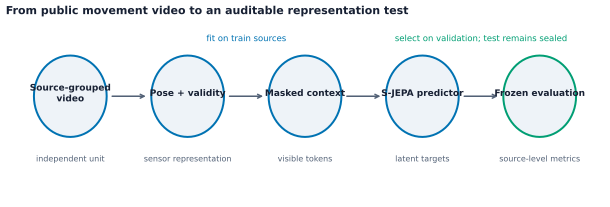

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_method_map.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_method_map.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_method_map.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_method_map.pdf


In [11]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "00",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)


## Interpretations and takeaways

The saved trace supports a narrow, useful conclusion: the teaching model produces matching target/prediction shapes, samples only allowed targets, computes a finite loss, and keeps the target encoder gradient-free.

It does not show learned gait structure, disease discrimination, clinical validity, or future prediction. No optimizer update or real-data training is demonstrated here. In particular, do not copy this architecture description into a report about notebook 04's checkpoints.

The core ideas to carry forward are:

1. A latent target is a learned vector, not a diagnosis or a coordinate.
2. A target mask and a source-level evaluation split protect different boundaries.
3. A valid measurement and a synthetically hidden measurement are different things.
4. Software checks are necessary, but useful health representations require separate empirical tests.

Next, use [notebook 01](01_gavd_manifest_and_youtube.ipynb) to establish which real sources exist and how their evaluation roles are assigned. See the [tutorial reading guide](docs/notebook_tutorial_guide.md) for the full sequence.
